In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import pipeline as pipeline
print(pipeline.__file__)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py


In [6]:
input_dir  = './input_data'
stage_dirs = ['amd_sim_data_Early_Hispanic', 'amd_sim_data_Intermediate_Hispanic', 'amd_sim_data_Late-dry_Hispanic', 'amd_sim_data_Late-wet_Hispanic']
stage      = stage_dirs[3]
print(stage)

pm_model = pipeline.initiliaze_pipeline(f'{input_dir}/{stage}', verbose=True) 

amd_sim_data_Late-wet_Hispanic
number of rows: 33
number of unique location_id: 1
number of nodes: 233
number of edges: 232


In [7]:
rate_types = ['beta_binom', 'binom', 'neg_binom', 'poisson', 'log_normal', 'normal', 'offset_log_normal']
rate_type = rate_types[2]

pipeline.generate_pymc_objects(pm_model, rate_type=rate_type, include_covariates=True)

Standard errors replaced: 0
Effective sample sizes filled: 0
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Series([], dtype: object)


In [8]:
map_estimate = pipeline.return_map_estimate(pm_model=pm_model, verbose=True)

INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


In [9]:
idata = pipeline.return_idata(pm_model     = pm_model, 
                            map_estimate   = map_estimate, 
                            draws          = 2000,
                            tune           = 1000,
                            chains         = 4,
                            cores          = 4,
                            target_accept  = 0.9,
                            max_treedepth  = 10,
                            use_advi       = False,
                            use_metropolis = True,
                            verbose=True
                            ) 
# 198.3초 소요

INFO:pipeline:  ▶ Metropolis 샘플링 수행 중...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [sigma_alpha_p_4_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_4_z]
>Metropolis: [beta_p_x_sdi]
INFO:pymc:>Metropolis: [beta_p_x_sdi]
>Metropolis: [beta_p_x_tob]
INFO:pymc:>Metropolis: [beta_p_x_tob]
>Metropolis: [beta_p_x_sex]
INFO:pymc:>Metropolis: [beta_p_x_sex]
>Metropolis: [eta_p]
INFO:pymc:>Metropolis: [eta_p]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.
INFO:pymc:Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
INFO:pipeline:[asr] 전체 소요 시간: 18.2초


In [10]:
summary_df = pipeline.return_rhat(idata)

Total vars:    455
R-hat > 1.01:  72
R-hat <= 1.01:  323
R-hat missing: 60
<xarray.Dataset> Size: 6kB
Dimensions:               (knot: 6, age: 101, cum_sum_mu_p_dim_0: 101,
                           mu_interval_p_dim_0: 33, pi_p_dim_0: 33,
                           obs_dim: 33, p_pred_p_dim_0: 33)
Coordinates:
  * knot                  (knot) float64 48B 0.0 30.0 45.0 60.0 80.0 100.0
  * age                   (age) float64 808B 0.0 1.0 2.0 3.0 ... 98.0 99.0 100.0
  * cum_sum_mu_p_dim_0    (cum_sum_mu_p_dim_0) int64 808B 0 1 2 3 ... 98 99 100
  * mu_interval_p_dim_0   (mu_interval_p_dim_0) int64 264B 0 1 2 3 ... 30 31 32
  * pi_p_dim_0            (pi_p_dim_0) int64 264B 0 1 2 3 4 5 ... 28 29 30 31 32
  * obs_dim               (obs_dim) int64 264B 0 1 2 3 4 5 ... 27 28 29 30 31 32
  * p_pred_p_dim_0        (p_pred_p_dim_0) int64 264B 0 1 2 3 4 ... 29 30 31 32
Data variables: (12/22)
    gamma_p               (knot) float64 48B 1.02 1.011 1.007 1.011 1.01 1.003
    sigma_alpha_p_0_z    

In [ ]:
pred = pipeline.predict_for(pm_model            = pm_model,
                            idata               = idata, 
                            root_area           = 'Global',
                            root_sex            = 'Both',
                            root_year           = 'all',
                            area                = 'Global',
                            sex                 = 'Both',
                            year                = 2019,
                            population_weighted = True,
                            lower               = 0.0,
                            upper               = 1.0,
                            )

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:759: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


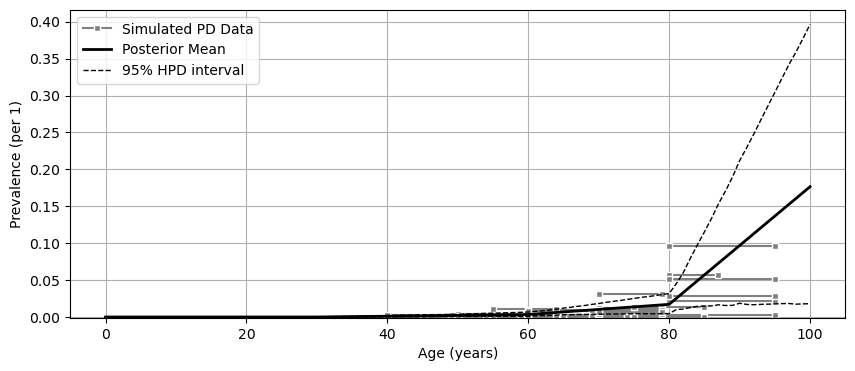

In [12]:
pipeline.visualize_pred(pred, pm_model.shared_data["data"])